## Task-based model of automation

### 1. Motivation and Economic setup

*Questions to answer*
1. What question is the model trying to answer?

...

2. What are the key economic phenomena I want to capture?
3. Why are existing approaches (factor-augmenting) insufficient?

The **Task-based model** was created as a way to capture the substitution effect of technological change. Previously, most economists used a factor-augmenting model given by:
$$ Y = F(A_K K, A_L L)$$

Where: 

| Variable |   Description            |
|----------|--------------------------|
| Y        | total output (the economy)|
| K        | capital |
| L        | labour  |
| $A_K$ | capital-augmenting technology |
| $A_L$ | labour-augmenting technology |

One of the most important distinctions between factor-augmenting and task-based models is how they define the replacability between labour and capital. The factor-augmenting model defines it as:

$$ \epsilon_{KL} = - \frac{d \ln(F_K/F_L)}{d \ln(K/L)} > 0$$

Wages (W) and Capital (K) adjust in equilibrium. The result of automation in a factor-augmenting model is that when capital improves (becomes more efficient) wages *always* rise. And the effects depend on how easily can firms substitute $K$ for $L$: exactly what $\epsilon_{KL}$ measures.



#### 1.1 The problem with Factor-Augmenting Models

Standard macroeconomic approaches model technology as factor augmenting  and relying on the standard CES production function:

$$ Y = [\alpha (A_K K)^{\frac{\sigma - 1}{\sigma}} + (1 - \alpha)(A_L L)^{\frac{\sigma - 1}{\sigma}}]^{\frac{\sigma - 1}{\sigma}} $$

Where wage $W$ is the marginal product of labour:

$$ W = \frac{\partial Y}{\partial L} $$

*These equations are fundamental macroeconomic equations (Arrow & Sollow et al., 1961)*

This framework implies that any improvement in capital technology ($A_K$) will *always increase* labour demand and wages. However, this framework fails to capture the displacement effect of automation.

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def solve_factor_augmenting(A_K, A_L=1.0, K=3.0, L=1.0, sigma=0.7, alpha=0.5):
    power = (sigma - 1) / sigma
    
    # CES Production Function
    Y = (alpha * (A_K * K)**power + (1-alpha) * (A_L * L)**power)**(1/power)
    
    # Wage = Marginal Product of Labor (dY/dL)
    # W = (1-alpha) * A_L^power * (Y / L)^(1/sigma)
    W = (1 - alpha) * (A_L**power) * (Y / L)**(1/sigma)
    
    return W

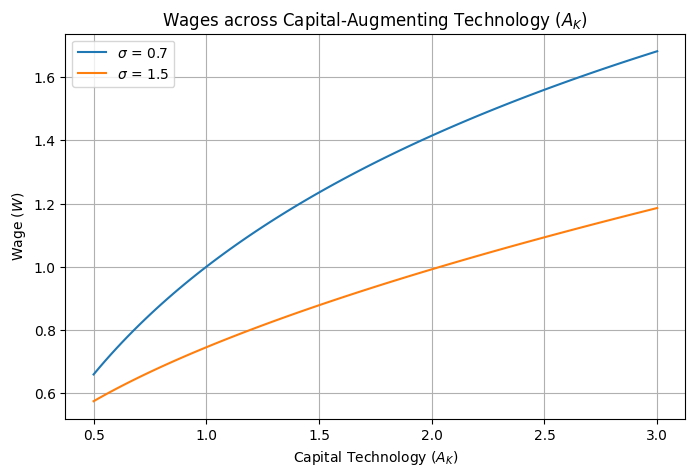

In [66]:
A_K_grid = np.linspace(0.5, 3.0, 100)
sigmas = [0.7, 1.5]

fig, ax = plt.subplots(figsize=(8, 5))

for sig in sigmas:
    wages = []
    for ak in A_K_grid:
        wage = solve_factor_augmenting(ak, sigma=sig)
        wages.append(wage)

    ax.plot(A_K_grid, wages, label=rf'$\sigma$ = {sig}')

ax.set_title('Wages across Capital-Augmenting Technology ($A_K$)')
ax.set_xlabel('Capital Technology ($A_K$)')
ax.set_ylabel('Wage ($W$)')
ax.grid(True)
ax.legend()
plt.show()

We can see that wages always rise with technological progress. However, this model does not account for full replacability. Some jobs can disappear entirely as the result of automation. This is why instead of modelling the economy as capital and labour multiplied by productivity Acemoglu & Restrepo use a **task-based approach**.

In this framework the economy is the aggregate of all tasks that people and machines do (Acemoglu & Restrepo, 2018).  

### 2. Assumtions and definitions for Task-based Model

#### Definition 1 (Task Space)

The economy produces total output by combining a continues range of tasks indexed by $i \in [N-1, N]$. The interval is normalised to 1 which simplifies the aggregation as it is simpler to work on a unitary square. 

So why not use $i \in [0, 1]$?

$N$ is used to govern the lower and upper boundary of the task space, i.e. tasks that already disappeared or tasks which have not been yet created (for more detail please see section III on *New Tasks* of Amecoglu & Restapo paper).

#### Definition 2 (Production Technology)

Total output is a CES agggregate over individual task outputs:

$$
Y = \left(\int_0^N y(i)^{\frac{\sigma-1}{\sigma}}\,di\right)^{\frac{\sigma}{\sigma-1}}
$$

Where $\sigma > 0$ is the elasticity of substitution between tasks.

Value          |  Meaning  | Labour share |
---------------|-------------|----------------------
| $\sigma \to \infty$ |   perfect substitutes   | decreases
| $\sigma \to 0$ | perfect complements (Leontief)| increases
| $\sigma = 1$ | Cobb-Douglas benchmark | static


*Note that in the code $\frac{\sigma-1}{\sigma}$ is defined as "power"*

#### Definition 3 (Automation Threshold)

$I \in [N - 1, N]$ is the *automation threshold* - the marginal task that can be completed by a machine. 

Tasks $i \le I$ - automated <br>
Tasks $i > I$ - non-automated

We are modelling automation by expanding the $I$ boundary. Machines expanding into tasks previously reserved just for labour is the *extensive margin* of automation. While the increase of the efficiency of machines for tasks already in $[N-1, I]$ which refers to an increase in $\eta (i)$ is the *intensive margin* of automation.

#### Assumtion 1 (Comparative advantage of labour)

Labor has a systematic comparative advantage in more complex, higher-indexed tasks, whereas capital (machines/AI) has a comparative advantage in routine, lower-indexed tasks.

The ratio of labor productivity to capital productivity
$\frac{\gamma(i)}{\eta(i)}$ is strictly increasing in $i$.

Not all tasks are created equal. Tasks are ordered from most least to most "complex" (I've put it in brackets as there is no single definition to what complexity actually is). Tasks with a low $i$ index represent routine, well-defined set of activities (basic calculation, assembly line work or routine data handling) where machines excel as for these tasks the biggest problem becomes human error. As we move up the task space ($i$ increases) tasks become more complex, they require abstract reasoning, human judgement and context. 

*Why does this matter?*

This assumption is mathematically critical as it guarantees that there is exactly **one** automation threshold $I$ below which tasks are done by machines and above by humans.

#### Assumption 2 (It is all about the money)

Below the automation threshold $I$ it must be strictly cheaper to produce using capital:

$$\frac{\gamma(i)}{\eta(i)} < \frac{W}{R}$$

Where $W$ is the wage and $R$ is the rental rate of capital. 

The driver of technological progress is the decrease of computing price (cite Deming). In broader economical terms *it doesn't matter what the machine can do if a human can do it cheaper*. When this assumption fails, an increase of I has no effect on labour/capital allocations because no tasks near the automation threshold would switch to capital anyway.

**It's not enough to invent a machine; it must be cost-effective**

### 3. Solving the static task-based model

This section replicates Amecoglu & Restrepo task-based model for 2 different $\sigma$ values:

$\sigma = 0.7$ - tasks in the economy complement each other and are hard to substitute; <br>
$\sigma = 1.5$ - tasks are replacable and it is easier to use knowledge and experience with one task and successfully apply it to another one.

In [67]:
# ===============================
# ======== PARAMETERS ===========
# ===============================

# This will be a bit more useful towards the later stage. 
# I will set most of the mmanually inside of functions 
# (I think it is prettier). But in case I change my mind

N=1
# Tasks i ∈ [0, 1] unless N is varied

n = 1000
i = np.linspace(N-1, N, n)
h = i[1] - i[0]

In [68]:
def solve_static_model(task_grid, I, sigma, h=h, K=3.0, L=1.0, n=1000) -> dict:

    # these are numpy arrays because multiplied by i
    # make labor better at big i, and machines better at small i
    gamma = 0.2 + 0.5 * task_grid
    eta = 0.7 - 0.5 * task_grid   

    # CES
    power = (sigma - 1) / sigma

    # [0, I]
    capital_tasks = task_grid <= I
    # (I, 1]
    labour_tasks = task_grid > I

    # solving integrals using Rieman sums
    A_K = np.sum(eta[capital_tasks] ** power) * h
    A_L = np.sum(gamma[labour_tasks] ** power) * h

    # output
    Y = (A_K ** (1 / sigma) * K ** power + A_L ** (1 / sigma) * L ** power) ** (1/power)

    # wage and rental rate
    W = (Y * A_L / L) ** (1/sigma)
    R = (Y * A_K / K) ** (1/sigma)

    s_L = (W * L) / Y

    return {
        "Y": Y, 
        "W": W, 
        "R": R, 
        "s_L": s_L
    }

In [69]:
def solve_on_I_domain(task_grid, I_domain, sigma, K=3.0, L=1.0):

    results = {
        'Y': np.zeros_like(I_domain, dtype=float),
        'W': np.zeros_like(I_domain, dtype=float),
        'R': np.zeros_like(I_domain, dtype=float),
        's_L': np.zeros_like(I_domain, dtype=float)
    }  

    for k, I in enumerate(I_domain):
        model = solve_static_model(task_grid, I, sigma=sigma, K=K, L=L)

        results["Y"][k] = model["Y"]
        results["W"][k] = model["W"]
        results["R"][k] = model["R"]
        results["s_L"][k] = model["s_L"]


    return results


In [70]:
sigmas = [0.7, 1.5]

scenarios = {}
for sigma in sigmas:
    scenario = solve_on_I_domain(i, i, sigma=sigma)
    scenarios[sigma] = scenario

### 3.1 Baseline results

In [71]:
def plot_variable(I_domain, scenarios, variable, title, ylabel, ax=None):
    if ax is None:
        ax = plt.gca()

    for sigma, results in scenarios.items():
        ax.plot(I_domain, results[variable], label=rf'$\sigma$ = {sigma}')

    ax.set_title(title)
    ax.set_xlabel("Automation (I)")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend()


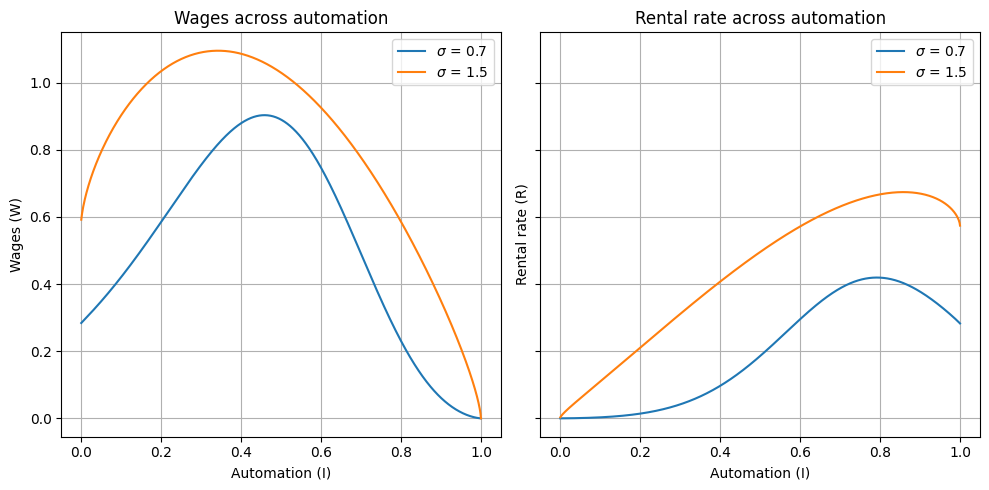

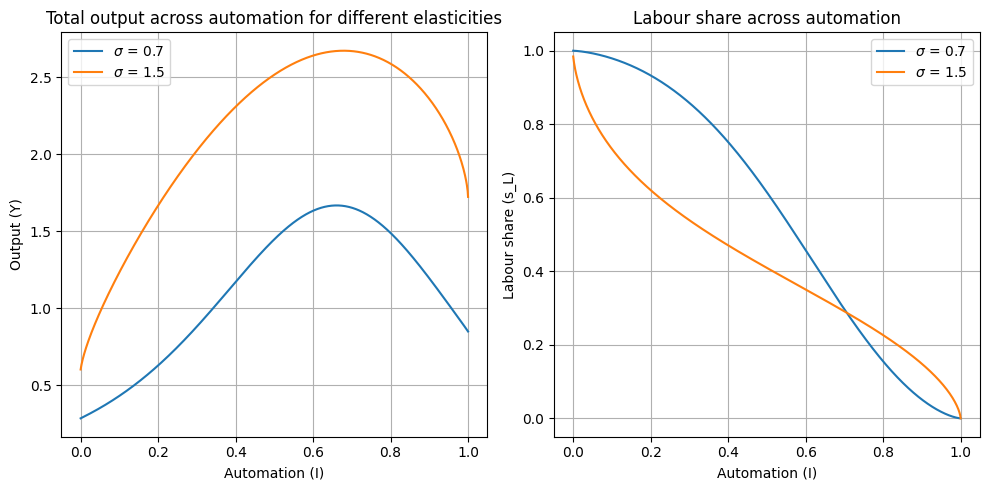

In [72]:
fig1, axs1 = plt.subplots(1, 2, sharey=True, figsize=(10, 5))

plot_variable(i, scenarios, "W", "Wages across automation", "Wages (W)", ax=axs1[0])
plot_variable(i, scenarios, "R", "Rental rate across automation", "Rental rate (R)", ax=axs1[1])

plt.tight_layout()
plt.show()

fig2, axs2 = plt.subplots(1, 2, figsize=(10, 5))

plot_variable(i, scenarios, 'Y', 'Total output across automation for different elasticities', 'Output (Y)', ax=axs2[0])
plot_variable(i, scenarios, "s_L", "Labour share across automation", "Labour share (s_L)", ax=axs2[1])


plt.tight_layout()
plt.show()


In [73]:
# ===============================
#  FULLY AI CREATED INTERACTIVE PLOT
# ===============================
# I just changed the limits and figure size to make it look better in the notebook, but the rest is fully AI generated.

import io
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

# Create the figure with 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
initial_sigma = 0.7
initial_results = solve_on_I_domain(i, i, sigma=initial_sigma)

# Unpack axes
ax_Y, ax_W = axs[0, 0], axs[0, 1]
ax_R, ax_sL = axs[1, 0], axs[1, 1]

# 1. Plot Output (Y)
line_Y, = ax_Y.plot(i, initial_results["Y"], color="tab:green", linewidth=2)
ax_Y.set_title(rf"Total output across automation | $\sigma = {initial_sigma:.2f}$")
ax_Y.set_xlabel("Automation (I)")
ax_Y.set_ylabel("Output (Y)")
ax_Y.set_ylim(0, 6.0)
ax_Y.grid(True)

# 2. Plot Wages (W)
line_W, = ax_W.plot(i, initial_results["W"], color="tab:blue", linewidth=2)
ax_W.set_title(rf"Wages across automation | $\sigma = {initial_sigma:.2f}$")
ax_W.set_xlabel("Automation (I)")
ax_W.set_ylabel("Wages (W)")
ax_W.set_ylim(0, 1.5)
ax_W.grid(True)

# 3. Plot Rental rate (R)
line_R, = ax_R.plot(i, initial_results["R"], color="tab:orange", linewidth=2)
ax_R.set_title(rf"Rental rate across automation | $\sigma = {initial_sigma:.2f}$")
ax_R.set_xlabel("Automation (I)")
ax_R.set_ylabel("Rental rate (R)")
ax_R.set_ylim(0, 1.5)
ax_R.grid(True)

# 4. Plot Labour share (s_L)
line_sL, = ax_sL.plot(i, initial_results["s_L"], color="tab:red", linewidth=2)
ax_sL.set_title(rf"Labour share across automation | $\sigma = {initial_sigma:.2f}$")
ax_sL.set_xlabel("Automation (I)")
ax_sL.set_ylabel("Labour share (s_L)")
ax_sL.set_ylim(0, 1.05)
ax_sL.grid(True)

plt.tight_layout()
plt.close(fig) # Prevent Matplotlib from automatically rendering underneath

# Create an Image widget to hold the rendered plot
img_widget = widgets.Image(format='png')

def update_image():
    buf = io.BytesIO()
    fig.savefig(buf, format='png') 
    buf.seek(0)
    img_widget.value = buf.read()

# Initialize the image
update_image()

sigma_slider = widgets.FloatSlider(
    value=initial_sigma,
    min=0.2,
    max=5.0,
    step=0.05,
    description="sigma",
    continuous_update=True,
    readout_format=".2f",
)

def on_sigma_change(change):
    sigma = change['new']
    
    # Skip exactly 1.0 as it's the Cobb-Douglas benchmark and raises divide by zero for CES
    if abs(sigma - 1.0) < 1e-4:
        sigma = 1.01
        
    results = solve_on_I_domain(i, i, sigma=sigma)
    
    # Fast update of the data & titles (axis limits remain fixed!)
    line_Y.set_ydata(results["Y"])
    ax_Y.set_title(rf"Total output across automation | $\sigma = {sigma:.2f}$")
    
    line_W.set_ydata(results["W"])
    ax_W.set_title(rf"Wages across automation | $\sigma = {sigma:.2f}$")
    
    line_R.set_ydata(results["R"])
    ax_R.set_title(rf"Rental rate across automation | $\sigma = {sigma:.2f}$")
    
    line_sL.set_ydata(results["s_L"])
    ax_sL.set_title(rf"Labour share across automation | $\sigma = {sigma:.2f}$")
    
    # Save the new frame and push to the widget
    update_image()

sigma_slider.observe(on_sigma_change, names="value")

# Display them stacked
display(widgets.VBox([sigma_slider, img_widget]))

ValueError: 
Physical Complexity (j) $ightarrow$
                        ^
ParseException: Expected end of text, found '$'  (at char 24), (line:1, col:25)

In [74]:
# Export commands on windows
# jupyter nbconvert --to html main.ipynb
# Start-Process -FilePath "msedge" -ArgumentList "--headless --disable-gpu --run-all-compositor-stages-before-draw --print-to-pdf=`"$PWD\main.pdf`" `"$PWD\main.html`"" -Wait

### Augmenting the model for modern reality of Generative AI

Right now the model evaluates a task as automated only if it is fully done by a machine. But with current technology, in particular with advancements in LLMs a lot of tasks are done with some combination of human labour and machine capital. AI can act as a copilot which can change how we define automation from a binary "Either capital or labour" to "Capital or Labour OR both".

Instead of ordering tasks on a single 1D complexity line (i), I am defining tasks as two coordinates ($i$, $j$) inside a 2D Domain D (on a unitary square). Where:

- $i \in [0, 1]$ represents **Cognitive Complexity** (0 = simple logic, 1 = abstract resoning/creativity)
- $j \in [0, 1]$ represents **Physical Complexity*** (0 = repetitive motion, 1 = intricate motion/hard labour)

A single task is on a $(i,j)$ point on this grid.

We assume that humans are generally better, but especially good at high cognitive ($i$) and high physical ($j$), while machines are excellent at low cognitive (routine calculations) and low physical (assembly lines), but struggle with complexity.

To satisfy this assumption I will model AI development the same way we model the heat diffusion process over time:

$$
\frac{\partial u}{\partial t}=\nabla^2 u
$$


We solve this using the finite differences method we get:

$$
U_{i,j,n+1} \approx r(U_{i+1,j,n}+U_{i-1,j,n}+U_{i,j+1,n}+U_{i,j-1,n}) + (1 - 4r)U_{i,j,n}
$$

With:
$$
0 \le r \le \frac{1}{4}
$$

Where:
$$
r = \frac{\Delta t}{h^2}
$$

*For mote information chech out my github repository of modelling the heat equation on a circular domain*:
https://github.com/Doctor2007/heat_eq_on_circle/

We start with machines master

In [94]:
# Grid setup 

def assemble_grid(N): 
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    h = x[1] - x[0]

    I, J = np.meshgrid(x, y)

    automation_matrix = np.zeros((N,N))

    # We start from the origin point (the first machine learning the simplest task).

    automation_matrix[0,0] = 1

    return automation_matrix

In [95]:
def laplacian(T, r, i, j):
    return r*(T[i+1, j] + T[i-1,j] + T[i, j+1] + T[i, j -1]) + (1-4*r)*T[i,j]

In [ ]:
T = assemble_grid(100)

100

In [ ]:
def run_simulation(N, r, t_steps, boundary_val, tol=1e-6):
    """
    Takes in:
    N - grid size
    r - diffusion (dt / h**2)
    t_steps - number of time steps
    outise: mask of outside points (False)
    boundary_val - fixed boundary temperature that we are applying

    Returns:
    T_end - final temperature grid
    history - array of T grids
    """
    T = assemble_grid(N)
    history = [T.copy()]

    for n in range(t_steps):
        T_new = T.copy()

        for i in range(N - 1):

            T_new[i, j] = laplacian(T, r, i, j)

        T_new[outside] = boundary_val

        # This will be later useful for convergence analysis to find 
        # if the maximum changes decrease over time
        # This simply looks at the biggest change on a new grid (T_new) from old grid (T)
        change = np.abs(T_new[~outside] - T[~outside])
        max_change = np.max(change)
        max_changes.append(max_change)


        T = T_new
        history.append(T.copy())

        # I was trying to optimise and AI suggested this logic
        # I think it is good to have in case someone wants to modify the code later and chooses a big number for t_steps
        if max_change < tol:
            print(f"Converged at step {n}")
            break

    return T, history, max_changes